In [1]:
import pandas as pd
import json

with open('dataset-telecon.json') as f:
    json_bruto = json.load(f)

dados_normalizados = pd.json_normalize(json_bruto)

idx = dados_normalizados[dados_normalizados['conta.cobranca.Total'] == ' '].index

dados_normalizados.loc[idx,'conta.cobranca.Total'] = dados_normalizados.loc[idx,'conta.cobranca.mensal'] * 24
dados_normalizados.loc[idx,'cliente.tempo_servico'] = 24
dados_normalizados['conta.cobranca.Total'] = dados_normalizados['conta.cobranca.Total'].astype(float)
dados_sem_vazio = dados_normalizados[dados_normalizados['Churn'] != ''].copy()
dados_sem_vazio.reset_index(drop=True, inplace=True)

dados_sem_vazio.drop_duplicates(inplace=True)

In [2]:
filtro = dados_sem_vazio['cliente.tempo_servico'].isna()

dados_sem_vazio[filtro][['cliente.tempo_servico', 'conta.cobranca.mensal', 'conta.cobranca.Total']]

import numpy as np

dados_sem_vazio['cliente.tempo_servico'].fillna(
    np.ceil(
        dados_sem_vazio['conta.cobranca.Total'] / dados_sem_vazio['conta.cobranca.mensal']
    ), inplace=True
)

colunas_to_drop = ['conta.contrato','conta.faturamente_eletronico', 'conta.metodo_pagamento']

df_sem_nulos = dados_sem_vazio.dropna(subset=colunas_to_drop).copy()

df_sem_nulos.reset_index(inplace=True, drop=True)

In [3]:
df_sem_nulos.describe()

,cliente.idoso,cliente.tempo_servico,conta.cobranca.mensal,conta.cobranca.Total
count,7006.000000,7006.000000,7006.000000,7006.000000
mean,0.162004,33.286183,64.720361,2317.743862
std,0.368481,35.311206,30.084664,2876.919022
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.450000,402.087500
50%,0.000000,29.000000,70.300000,1392.925000
75%,0.000000,56.000000,89.850000,3783.600000
max,1.000000,1080.000000,118.750000,112212.000000


In [4]:
import seaborn as sns

c:\Users\leoka\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\leoka\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='cliente.tempo_servico'>

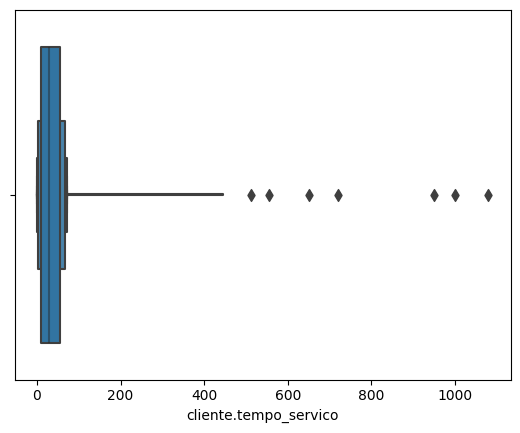

In [5]:
sns.boxenplot(x=df_sem_nulos['cliente.tempo_servico'])

In [6]:
Q1 = df_sem_nulos['cliente.tempo_servico'].quantile(.25)

Q3 = df_sem_nulos['cliente.tempo_servico'].quantile(.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR

limite_superior = Q3 + 1.5 * IQR

In [7]:
outliers_index = (df_sem_nulos['cliente.tempo_servico'] < limite_inferior) | (df_sem_nulos['cliente.tempo_servico'] > limite_superior) 

In [8]:
df_sem_nulos[outliers_index]['cliente.tempo_servico']

1945    1080.0
1946    1000.0
1952     950.0
1956     254.0
1958     321.0
1963     650.0
1966     721.0
1970     555.0
1973     433.0
1974     512.0
Name: cliente.tempo_servico, dtype: float64

In [9]:
df_sem_out = df_sem_nulos.copy()

In [10]:
df_sem_out[outliers_index]['cliente.tempo_servico']

1945    1080.0
1946    1000.0
1952     950.0
1956     254.0
1958     321.0
1963     650.0
1966     721.0
1970     555.0
1973     433.0
1974     512.0
Name: cliente.tempo_servico, dtype: float64

In [11]:
df_sem_out.loc[outliers_index, 'cliente.tempo_servico'] = np.ceil(
    df_sem_out.loc[outliers_index, 'conta.cobranca.Total'] / df_sem_out.loc[outliers_index, 'conta.cobranca.mensal']
)

c:\Users\leoka\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\leoka\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='cliente.tempo_servico'>

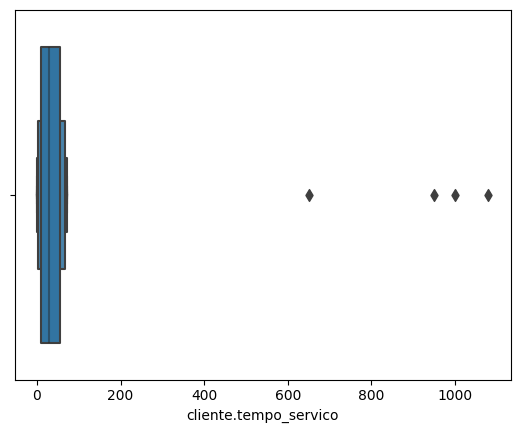

In [12]:
sns.boxenplot(x=df_sem_out['cliente.tempo_servico'])

In [13]:
df_sem_out[outliers_index][['cliente.tempo_servico', 'conta.cobranca.mensal', 'conta.cobranca.Total']]

,cliente.tempo_servico,conta.cobranca.mensal,conta.cobranca.Total
1945,1080.0,103.90,112212.00
1946,1000.0,45.90,45900.00
1952,951.0,84.10,79895.00
1956,2.0,46.05,80.35
1958,43.0,99.80,4259.30
1963,650.0,73.00,47450.00
1966,44.0,89.55,3856.75
1970,7.0,19.15,124.40
1973,4.0,89.20,346.20
1974,1.0,19.55,19.55


In [15]:
Q1 = df_sem_out['cliente.tempo_servico'].quantile(.25)

Q3 = df_sem_out['cliente.tempo_servico'].quantile(.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR

limite_superior = Q3 + 1.5 * IQR

outliers_index = (df_sem_out['cliente.tempo_servico'] < limite_inferior) | (df_sem_out['cliente.tempo_servico'] > limite_superior) 

In [17]:
df_sem_out = df_sem_out[~outliers_index]

c:\Users\leoka\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\leoka\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='cliente.tempo_servico'>

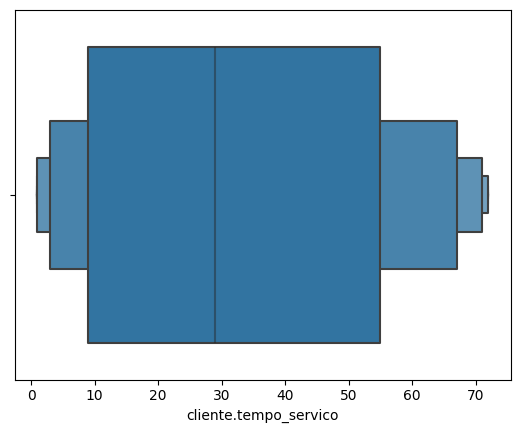

In [20]:
sns.boxenplot(x=df_sem_out['cliente.tempo_servico'])